In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [25]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [26]:
N_AB_sub = np.loadtxt('../../../misc/ForSebastian/N_AB_sub_BolPlanck.dat')

cols = [
    "host_id", "logMh", "ch", "a_50h",
    "Xoff_h", "Spin_h", "Spin_Bullock_h", "ch_K",
    "x_h", "y_h", "z_h", "R_vir",
    "id", "log10Mvir", "Rvir", "rs", "vrms", "scale_of_last_MM",
    "vmax", "x", "y", "z", "vx", "vy", "vz",
    "Jx", "Jy", "Jz", "Spin", "Tidal_Force", "Tidal_ID",
    "Mmvir_all", "M200b", "M200c", "M500c",
    "Xoff", "Voff", "Spin_Bullock",
    "b_to_a", "c_to_a",
    "Ax", "Ay", "Az", "T_by_U",
    "M_pe_Behroozi", "M_pe_Diemer",
    "Macc", "Mpeak", "Vacc", "Vpeak", "Halfmass_Scale",
    "Acc_Rate_Inst", "Acc_Rate_100Myr", "Acc_Rate_1Tdyn",
    "Acc_Rate_2Tdyn", "Acc_Rate_Mpeak",
    "Mpeak_Scale", "Acc_Scale", "First_Acc_Scale",
    "First_Acc_Mvir", "First_Acc_Vmax", "Vmax_at_Mpeak",
    "Tidal_Force_Tdyn"
]

df = pd.DataFrame(N_AB_sub, columns=cols)

In [ ]:
def build_host_table(df, mass_thresh):

    host_id_unique = np.sort(df["host_id"].unique())

    logMvir   = np.zeros(len(host_id_unique))
    log1pz50  = np.zeros(len(host_id_unique))
    logc      = np.zeros(len(host_id_unique))
    logNsub   = np.zeros(len(host_id_unique))
    logfsub   = np.zeros(len(host_id_unique))

    groups = df.groupby("host_id")

    for i, hid in enumerate(host_id_unique):

        subset = groups.get_group(hid)
        subset1 = subset[subset["log10Mvir"] >= mass_thresh]

        # --- host properties ---
        logMh_i  = subset["logMh"].mean()
        c_h_i    = subset["ch"].mean()
        a_half_i = subset["a_50h"].mean()

        # --- derived quantities ---
        z50 = (1.0 / a_half_i) - 1.0

        Nsub_i = len(subset1)

        host_mass = 10**logMh_i
        sub_mass_total = np.sum(10**subset1["log10Mvir"])
        f_sub_i = sub_mass_total / host_mass

        # --- logs (with safety) ---
        logMvir[i]  = logMh_i
        log1pz50[i] = np.log10(1.0 + z50)

        logc[i] = np.log10(c_h_i)

        logNsub[i] = np.log10(Nsub_i) if Nsub_i > 0 else -np.inf

        logfsub[i] = np.log10(f_sub_i) if f_sub_i > 0 else -np.inf

        if (i % 10000) == 0:
            print(i)

    small_df = pd.DataFrame({
        "host_id": host_id_unique,
        "logMvir": logMvir,
        "log1pz50": log1pz50,
        "logc": logc,
        "logNsub": logNsub,
        "logfsub": logfsub
    })

    return small_df

In [28]:
# Identify unique hosts and compute host-level properties
host_props = df.groupby("host_id")[["Xoff_h", "Spin_h", "R_vir"]].mean()

# Apply the cut
both_cut = host_props[
    (host_props["Xoff_h"]/host_props["R_vir"] <= 0.07) &
    (host_props["Spin_h"] <= 0.07)
].index

# Apply the cut
xoff_cut = host_props[
    (host_props["Xoff_h"]/host_props["R_vir"] <= 0.07)
].index

# Filter dataframe to keep only those hosts
both = df[df["host_id"].isin(both_cut)]
xoff = df[df["host_id"].isin(xoff_cut)]

In [29]:
both_df = build_host_table(both, mass_thresh=9.82)
xoff_df = build_host_table(xoff, mass_thresh=9.82)
full_df = build_host_table(df, mass_thresh=9.82)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
2

(0.0, 0.7)

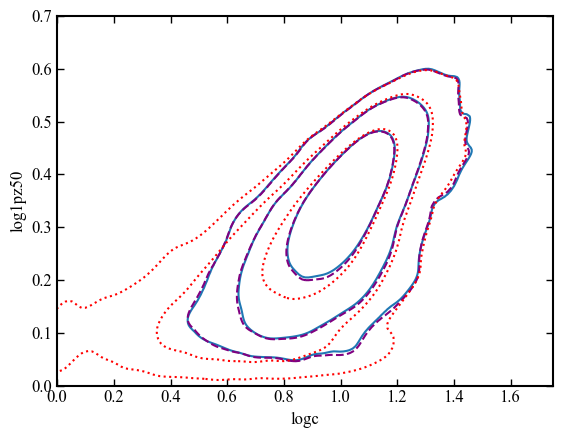

In [30]:
sns.kdeplot(x=both_df["logc"], y=both_df["log1pz50"], levels=levelz, color="C0", bw_adjust=1.5)
sns.kdeplot(x=xoff_df["logc"], y=xoff_df["log1pz50"], levels=levelz, color="purple", linestyles="--", bw_adjust=1.5)
sns.kdeplot(x=full_df["logc"], y=full_df["log1pz50"], levels=levelz, color="red", linestyles=":", bw_adjust=1.5)
plt.xlim(0, 1.75)
plt.ylim(0, 0.7)

In [31]:
both_df.to_csv("../../data/summary_tabs/bolshoi_full.csv")